# NB08: Analyse secondaire TF-IDF vs BioClinicalBERT

Ce notebook compare deux façons de représenter le motif de recours aux urgences : **TF-IDF** et **BioClinicalBERT**.

L'objectif est volontairement limité : vérifier si BioClinicalBERT apporte un gain discriminatif par rapport à TF-IDF sur des motifs de recours courts. Cette analyse reste secondaire par rapport au modèle opérationnel principal.

In [1]:
# ============================================================
# IMPORTS UNIQUES + CONFIGURATION
# Comparatif TF-IDF + RF vs BioClinicalBERT — MIMIC-IV ED
# ============================================================
from __future__ import annotations

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["HF_DATASETS_VERBOSITY"] = "error"

import sys
import gc
import json
import glob
import shutil
import pickle
import random
import inspect
import logging
import warnings
import subprocess
import importlib.util
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import joblib

from scipy.sparse import hstack as sp_hstack, csr_matrix, save_npz

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
)

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import torch
    TORCH_OK = True
except Exception as exc:
    torch = None
    TORCH_OK = False
    TORCH_IMPORT_ERROR = exc

try:
    import datasets as ds_lib
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModel,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding,
        logging as hf_logging,
    )
    HF_OK = True
except Exception as exc:
    HF_OK = False
    HF_IMPORT_ERROR = exc

warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)
for _logger_name in ["transformers", "datasets", "torch", "accelerate", "peft"]:
    logging.getLogger(_logger_name).setLevel(logging.ERROR)

if HF_OK:
    hf_logging.set_verbosity_error()
    ds_lib.disable_progress_bar()
    ds_lib.utils.logging.set_verbosity_error()

ENV = "colab" if importlib.util.find_spec("google.colab") else "jupyter"

#  Chemins projet — bloc unifié, identique dans NB01 -> NB08
def _racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Racine = 1er dossier (courant ou parent) contenant un dossier repere."""
    for _p in (Path.cwd(), *Path.cwd().parents):
        if any((_p / _m).is_dir() for _m in reperes):
            return _p
    return Path.cwd()

ROOT_DIR   = _racine_projet()
BASE       = ROOT_DIR / "data"
OUT_DIR    = ROOT_DIR / "data" / "processed"
SPLIT_DIR  = OUT_DIR / "splits"
FIG_DIR    = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR  = RESULT_DIR / "tables"
MODEL_DIR  = ROOT_DIR / "models"
for _d in (OUT_DIR, SPLIT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)

PROJECT_DIR = BASE.resolve().parent

# Chemins 
DATA_DIR  = OUT_DIR                       # cohorte d'entrée = data/processed
BERT_DIR  = RESULT_DIR / "bert_analyse"   # sorties spécifiques à l'analyse BERT
BERT_DIR.mkdir(parents=True, exist_ok=True)

# Fichier d'entrée 
DATA_PATH = OUT_DIR / "cohort_nlp.csv"

# Colonnes clés 
TARGET_COL = "target"
TEXT_COL   = "cleaned_complaint"
YEAR_COL   = "ayg_start"
GROUP_COL  = "subject_id"

# Split temporel 
VALID_YEAR = 2017

# Paramètres d'exécution 
RUN_TEXT_ONLY              = True
RUN_BERT_TEXT              = True
RUN_HYBRID                 = True
RUN_BERT_EMBEDDINGS_HYBRID = True

MAX_BERT_TRAIN = 5000
MAX_BERT_VAL   = 1000
MAX_BERT_CAL   = 1000
BERT_EPOCHS    = 1
BERT_BATCH     = 4
MAX_LENGTH     = 64
RANDOM_STATE   = 42

BERT_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
BERT_LR         = 2e-5

# Seuil clinique choisi sur validation, jamais sur test.
TARGET_SENSITIVITY = 0.90

print(f"Environnement : {ENV}")
print(f"PyTorch OK    : {TORCH_OK}")
print(f"HuggingFace OK: {HF_OK}")
if TORCH_OK:
    print(f"Torch         : {torch.__version__}")
    print(f"CUDA          : {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU           : {torch.cuda.get_device_name(0)}")


Environnement : jupyter
PyTorch OK    : True
HuggingFace OK: True
Torch         : 2.6.0+cu124
CUDA          : True
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU


---
## 1. Bloc technique

Les fonctions de préparation, d'entraînement, de métriques et de figures sont regroupées ci-dessous afin de garder le notebook lisible. Dans JupyterLab, ces cellules peuvent être repliées/masquées.

In [2]:
def set_seed(seed: int = RANDOM_STATE) -> None:
    """Fixe les graines aléatoires pour rendre les résultats plus reproductibles."""
    random.seed(seed)
    np.random.seed(seed)

    if TORCH_OK:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


def ensure_ayg_start(df: pd.DataFrame) -> pd.DataFrame:
    """Crée ayg_start à partir de anchor_year_group si nécessaire."""
    if YEAR_COL not in df.columns:
        if "anchor_year_group" not in df.columns:
            raise ValueError(
                f"Colonne {YEAR_COL} absente et anchor_year_group absente. "
                "Vérifier que cohort_nlp.csv contient une variable temporelle exploitable."
            )
        df = df.copy()
        extracted = df["anchor_year_group"].astype(str).str.extract(r"(\d{4})")[0]
        df[YEAR_COL] = pd.to_numeric(extracted, errors="coerce")
    return df


def load_data(path):
    """
    Charge cohort_nlp.csv sans saturer la mémoire.

    Corrections principales :
    - lecture uniquement des colonnes utiles ;
    - ajout de anchor_year_group pour pouvoir recréer ayg_start si besoin ;
    - fallback engine='python' si le moteur C de pandas plante ;
    - création de __row_id si absent.
    """

    if not path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {path}\n"
            "Exécuter d'abord NB01/NB02 pour générer data/processed/cohort_nlp.csv."
        )

    # Lecture légère de l'en-tête
    colonnes_disponibles = pd.read_csv(path, nrows=0).columns.tolist()

    colonnes_utiles = [
        # identifiants / split / cible / texte
        TEXT_COL, TARGET_COL, YEAR_COL, "anchor_year_group",
        "__row_id", "stay_id", GROUP_COL,

        # variables structurées principales
        "heartrate", "sbp", "dbp", "o2sat", "resprate", "temperature",
        "age_ed", "anchor_age", "pain", "acuity",
        "n_hosp_anterieures", "charlson_score", "charlson_score_simplifie",
        "gender", "arrival_transport",
        "hour", "day_of_week", "is_night", "is_weekend",

        # comorbidités possibles
        "myocardial_infarction", "congestive_heart_failure",
        "cerebrovascular_disease", "dementia", "chronic_pulmonary_disease",
        "mild_liver_disease", "diabetes_without_cc", "diabetes_with_cc",
        "renal_disease", "cancer", "metastatic_carcinoma", "hiv",
        "aids", "copd", "heart_failure", "renal", "diabetes",
    ]

    if "STRUCT_COLS" in globals():
        colonnes_utiles += list(STRUCT_COLS)

    # Suppression des doublons et conservation des colonnes réellement présentes
    usecols = [c for c in dict.fromkeys(colonnes_utiles) if c in colonnes_disponibles]

    try:
        df = pd.read_csv(
            path,
            usecols=usecols,
            low_memory=True,
            engine="c",
        )
    except (pd.errors.ParserError, MemoryError) as exc:
        print(f"Lecture pandas moteur C impossible ({type(exc).__name__}). Relecture avec engine='python'.")
        df = pd.read_csv(
            path,
            usecols=usecols,
            low_memory=True,
            engine="python",
            on_bad_lines="skip",
        )

    # Identifiant de ligne stable pour tracer les splits
    if "__row_id" not in df.columns:
        df["__row_id"] = np.arange(len(df), dtype=np.int64)

    df = ensure_ayg_start(df)

    required = [TEXT_COL, TARGET_COL, YEAR_COL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes dans le fichier : {missing}")

    df = df.dropna(subset=[TEXT_COL, TARGET_COL, YEAR_COL]).copy()
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").astype("Int64")
    df = df.dropna(subset=[TARGET_COL]).copy()
    df[TARGET_COL] = df[TARGET_COL].astype(int)
    df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce").astype("Int64")
    df = df.dropna(subset=[YEAR_COL]).copy()
    df[YEAR_COL] = df[YEAR_COL].astype(int)

    return df


def split_train_val_cal_test(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    """
    Split scientifique :
    - test temporel : ayg_start >= VALID_YEAR
    - pool développement : ayg_start < VALID_YEAR
    - dans le pool : train / validation / calibration
    Si subject_id existe : split groupé patient-level dans le pool développement.
    """
    dev_df = df[df[YEAR_COL] < VALID_YEAR].copy().reset_index(drop=True)
    test_df = df[df[YEAR_COL] >= VALID_YEAR].copy().reset_index(drop=True)

    if len(dev_df) == 0 or len(test_df) == 0:
        raise ValueError("Split temporel impossible : dev ou test vide.")

    if GROUP_COL in dev_df.columns:
        print("Split interne groupé par patient dans le pool développement.")
        gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
        train_idx, temp_idx = next(gss1.split(dev_df, groups=dev_df[GROUP_COL]))
        train_df = dev_df.iloc[train_idx].copy().reset_index(drop=True)
        temp_df = dev_df.iloc[temp_idx].copy().reset_index(drop=True)

        gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_STATE)
        val_idx, cal_idx = next(gss2.split(temp_df, groups=temp_df[GROUP_COL]))
        val_df = temp_df.iloc[val_idx].copy().reset_index(drop=True)
        cal_df = temp_df.iloc[cal_idx].copy().reset_index(drop=True)

        # Contrôle overlap interne
        sets = {
            "train": set(train_df[GROUP_COL]),
            "val": set(val_df[GROUP_COL]),
            "cal": set(cal_df[GROUP_COL]),
        }
        assert len(sets["train"] & sets["val"]) == 0
        assert len(sets["train"] & sets["cal"]) == 0
        assert len(sets["val"] & sets["cal"]) == 0
    else:
        print("subject_id absent : split stratifié simple dans le pool développement.")
        train_df, temp_df = train_test_split(
            dev_df,
            test_size=0.30,
            stratify=dev_df[TARGET_COL],
            random_state=RANDOM_STATE,
        )
        val_df, cal_df = train_test_split(
            temp_df,
            test_size=0.50,
            stratify=temp_df[TARGET_COL],
            random_state=RANDOM_STATE,
        )
        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
        cal_df = cal_df.reset_index(drop=True)

    parts = {"train": train_df, "val": val_df, "cal": cal_df, "test": test_df}
    for name, part in parts.items():
        print(f"{name:<5} : {len(part):>8,} séjours | hosp. {part[TARGET_COL].mean():.1%}")

    # Attention : on ne supprime pas les patients du test temporel ayant un historique avant 2017.
    # C'est cohérent avec une validation temporelle réelle ; on peut l'auditer :
    if GROUP_COL in df.columns:
        overlap_temp = set(dev_df[GROUP_COL]) & set(test_df[GROUP_COL])
        print(f"Patients présents avant et après {VALID_YEAR} : {len(overlap_temp):,} (audit, pas une erreur).")

    return parts


def sample_for_bert(df: pd.DataFrame, max_n: Optional[int], name: str) -> pd.DataFrame:
    """Sous-échantillonne pour BERT en conservant approximativement la prévalence."""
    if max_n is None or len(df) <= max_n:
        return df.reset_index(drop=True)

    groups = []
    for _, grp in df.groupby(TARGET_COL):
        n = max(1, int(round(max_n * len(grp) / len(df))))
        n = min(n, len(grp))
        groups.append(grp.sample(n=n, random_state=RANDOM_STATE))

    out = pd.concat(groups).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Sous-échantillon BERT {name}: {len(df):,} -> {len(out):,}")
    return out


def safe_div(a: float, b: float) -> float:
    return float(a / b) if b else 0.0


def expected_calibration_error(y_true: np.ndarray, y_proba: np.ndarray, n_bins: int = 10) -> float:
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_proba >= lo) & (y_proba <= hi)
        else:
            mask = (y_proba >= lo) & (y_proba < hi)

        if mask.sum() == 0:
            continue

        conf = y_proba[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)

    return float(ece)


def platt_fit(proba_cal: np.ndarray, y_cal: np.ndarray) -> LogisticRegression:
    """Calibration de Platt ajustée uniquement sur l'échantillon de calibration."""
    lr = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(np.asarray(proba_cal).reshape(-1, 1), np.asarray(y_cal).astype(int))
    return lr


def platt_apply(calibrator: LogisticRegression, proba: np.ndarray) -> np.ndarray:
    return calibrator.predict_proba(np.asarray(proba).reshape(-1, 1))[:, 1]


def choisir_calibration_dynamique(
    y_val: np.ndarray,
    proba_val_raw: np.ndarray,
    y_cal: np.ndarray,
    proba_cal_raw: np.ndarray,
    proba_test_raw: np.ndarray,
    label: str,
    tol: float = 1e-4,
) -> Tuple[np.ndarray, np.ndarray, Optional[LogisticRegression], Dict[str, float | str]]:
    """
    Ajuste une calibration de Platt sur cal_df, puis décide sur validation
    s'il faut garder les probabilités calibrées ou les probabilités brutes.

    Critère principal : Brier sur validation.
    Critère secondaire en cas d'égalité : ECE10 sur validation.
    Le test temporel n'intervient jamais dans cette décision.
    """
    y_val = np.asarray(y_val).astype(int)
    y_cal = np.asarray(y_cal).astype(int)

    calibrator = platt_fit(proba_cal_raw, y_cal)
    proba_val_cal = platt_apply(calibrator, proba_val_raw)
    proba_test_cal = platt_apply(calibrator, proba_test_raw)

    brier_raw = brier_score_loss(y_val, proba_val_raw)
    brier_cal = brier_score_loss(y_val, proba_val_cal)
    ece_raw = expected_calibration_error(y_val, proba_val_raw, n_bins=10)
    ece_cal = expected_calibration_error(y_val, proba_val_cal, n_bins=10)

    use_calibrated = (brier_cal < brier_raw - tol) or (
        abs(brier_cal - brier_raw) <= tol and ece_cal < ece_raw
    )

    if use_calibrated:
        decision = "platt"
        proba_val_final = proba_val_cal
        proba_test_final = proba_test_cal
        calibrator_final = calibrator
    else:
        decision = "non_calibre"
        proba_val_final = np.asarray(proba_val_raw)
        proba_test_final = np.asarray(proba_test_raw)
        calibrator_final = None

    print(
        f"Calibration {label} : {decision} | "
        f"Brier val brut={brier_raw:.4f}, Platt={brier_cal:.4f} | "
        f"ECE val brut={ece_raw:.4f}, Platt={ece_cal:.4f}"
    )

    info = {
        "calibration_retenue": decision,
        "brier_val_brut": float(brier_raw),
        "brier_val_platt": float(brier_cal),
        "delta_brier_val_platt_moins_brut": float(brier_cal - brier_raw),
        "ece_val_brut": float(ece_raw),
        "ece_val_platt": float(ece_cal),
        "delta_ece_val_platt_moins_brut": float(ece_cal - ece_raw),
    }
    return proba_val_final, proba_test_final, calibrator_final, info


def choose_threshold_on_validation(
    y_val: np.ndarray,
    proba_val: np.ndarray,
    target_sensitivity: float = TARGET_SENSITIVITY,
    fallback: str = "youden",
) -> float:
    """
    Choisit le seuil sur validation.
    Le test temporel n'est jamais utilisé pour choisir le seuil.
    """
    fpr, tpr, thresholds = roc_curve(y_val, proba_val)
    eligible = np.where(tpr >= target_sensitivity)[0]

    if len(eligible) > 0:
        idx = int(eligible[0])
        return float(thresholds[idx])

    if fallback == "youden":
        idx = int(np.argmax(tpr - fpr))
        return float(thresholds[idx])

    return 0.5


def compute_metrics(y_true: np.ndarray, proba: np.ndarray, threshold: float, label: str) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba).astype(float)
    pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    se = safe_div(tp, tp + fn)
    sp = safe_div(tn, tn + fp)
    vpp = safe_div(tp, tp + fp)
    vpn = safe_div(tn, tn + fn)

    return {
        "modele": label,
        "n": int(len(y_true)),
        "threshold": float(threshold),
        "AUC": float(roc_auc_score(y_true, proba)),
        "AP": float(average_precision_score(y_true, proba)),
        "Brier": float(brier_score_loss(y_true, proba)),
        "ECE10": float(expected_calibration_error(y_true, proba, n_bins=10)),
        "Se": se,
        "Sp": sp,
        "VPP": vpp,
        "VPN": vpn,
        "BalancedAccuracy": float((se + sp) / 2),
        "VP": int(tp),
        "VN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "Alertes_100": float(100 * (tp + fp) / len(y_true)),
        "VP_100": float(100 * tp / len(y_true)),
        "FP_100": float(100 * fp / len(y_true)),
        "FN_100": float(100 * fn / len(y_true)),
    }


def bootstrap_delta_auc(
    y_true: np.ndarray,
    proba_a: np.ndarray,
    proba_b: np.ndarray,
    n_boot: int = 1000,
    seed: int = RANDOM_STATE,
) -> Dict[str, float]:
    """IC95 du delta AUC = AUC_B - AUC_A par bootstrap apparié."""
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true).astype(int)
    proba_a = np.asarray(proba_a).astype(float)
    proba_b = np.asarray(proba_b).astype(float)

    n = len(y_true)
    deltas = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        delta = roc_auc_score(y_true[idx], proba_b[idx]) - roc_auc_score(y_true[idx], proba_a[idx])
        deltas.append(delta)

    deltas = np.asarray(deltas, dtype=float)

    if len(deltas) == 0:
        return {
            "delta_auc_mean": np.nan,
            "delta_auc_p2_5": np.nan,
            "delta_auc_p97_5": np.nan,
            "n_boot_effectif": 0,
        }

    return {
        "delta_auc_mean": float(deltas.mean()),
        "delta_auc_p2_5": float(np.percentile(deltas, 2.5)),
        "delta_auc_p97_5": float(np.percentile(deltas, 97.5)),
        "n_boot_effectif": int(len(deltas)),
    }


def save_metrics(metrics: List[Dict[str, float]], filename: str) -> Path:
    """Sauvegarde les métriques dans le dossier BERT_DIR."""
    path = BERT_DIR / filename
    dfm = pd.DataFrame(metrics)
    dfm.to_csv(path, index=False)

    print("\n" + path.name)
    print(dfm.round(4).to_string(index=False))

    return path


def prepare_structured_features(parts: Dict[str, pd.DataFrame]) -> Tuple[Dict[str, np.ndarray], List[str], SimpleImputer, StandardScaler]:
    """
    Prépare les variables structurées :
    - variables numériques + indicateurs contextuels ;
    - encodage one-hot de gender et arrival_transport ;
    - imputation médiane + standardisation ajustées uniquement sur train.
    """
    combined = pd.concat(
        [
            parts["train"].assign(__part="train"),
            parts["val"].assign(__part="val"),
            parts["cal"].assign(__part="cal"),
            parts["test"].assign(__part="test"),
        ],
        axis=0,
        ignore_index=True,
    )

    base_numeric_cols = [
        "heartrate", "sbp", "dbp", "o2sat", "resprate", "temperature",
        "age_ed", "anchor_age", "pain", "acuity",
        "n_hosp_anterieures", "charlson_score_simplifie", "charlson_score",
        "hour", "day_of_week", "is_night", "is_weekend",

        # comorbidités fréquentes selon les versions NB01/NB02
        "myocardial_infarction", "congestive_heart_failure",
        "cerebrovascular_disease", "dementia", "chronic_pulmonary_disease",
        "mild_liver_disease", "diabetes_without_cc", "diabetes_with_cc",
        "renal_disease", "cancer", "metastatic_carcinoma", "hiv",
        "aids", "copd", "heart_failure", "renal", "diabetes",
    ]

    features_num = [c for c in base_numeric_cols if c in combined.columns]

    # Éviter les doublons conceptuels
    if "age_ed" in features_num and "anchor_age" in features_num:
        features_num.remove("anchor_age")
    if "charlson_score" in features_num and "charlson_score_simplifie" in features_num:
        features_num.remove("charlson_score_simplifie")

    X_df = pd.DataFrame(index=combined.index)

    for col in features_num:
        X_df[col] = pd.to_numeric(combined[col], errors="coerce")

    # Encodage du sexe
    if "gender" in combined.columns:
        gender_norm = (
            combined["gender"]
            .fillna("unknown")
            .astype(str)
            .str.strip()
            .str.lower()
        )
        dummies_gender = pd.get_dummies(gender_norm, prefix="gender", dtype=np.float32)
        X_df = pd.concat([X_df, dummies_gender], axis=1)

    # Encodage du mode d'arrivée
    if "arrival_transport" in combined.columns:
        transport_norm = (
            combined["arrival_transport"]
            .fillna("unknown")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"[\s\-]+", "_", regex=True)
        )
        dummies_transport = pd.get_dummies(transport_norm, prefix="arrival_transport", dtype=np.float32)
        X_df = pd.concat([X_df, dummies_transport], axis=1)

    features = X_df.columns.tolist()
    if not features:
        raise ValueError("Aucune variable structurée trouvée.")

    out = {}
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    train_mask = combined["__part"] == "train"
    X_train_raw = X_df.loc[train_mask, features].to_numpy(dtype=np.float32)
    X_train_imp = imputer.fit_transform(X_train_raw).astype(np.float32)
    out["train"] = scaler.fit_transform(X_train_imp).astype(np.float32)

    for part in ["val", "cal", "test"]:
        mask = combined["__part"] == part
        X_raw = X_df.loc[mask, features].to_numpy(dtype=np.float32)
        X_imp = imputer.transform(X_raw).astype(np.float32)
        out[part] = scaler.transform(X_imp).astype(np.float32)

    print(f"Variables structurées ({len(features)}) : {features}")

    joblib.dump(
        {"features": features, "imputer": imputer, "scaler": scaler},
        BERT_DIR / "structured_preprocess.pkl",
    )

    return out, features, imputer, scaler


def prepare_tfidf(
    parts: Dict[str, pd.DataFrame],
    max_features: int = 1000,
) -> Tuple[Dict[str, csr_matrix], TfidfVectorizer]:
    """Prépare les matrices TF-IDF avec fit uniquement sur train."""
    tfidf = TfidfVectorizer(
        max_features=max_features,
        min_df=5,
        ngram_range=(1, 2),
        sublinear_tf=True,
        dtype=np.float32,
    )

    X = {}
    X["train"] = tfidf.fit_transform(parts["train"][TEXT_COL].fillna("").astype(str))

    for part in ["val", "cal", "test"]:
        X[part] = tfidf.transform(parts[part][TEXT_COL].fillna("").astype(str))

    vocab = tfidf.get_feature_names_out().tolist()
    transfer_terms = [t for t in vocab if "transfer" in t]
    print(f"Vocabulaire TF-IDF : {len(vocab)} termes")
    print(f"Termes contenant 'transfer' : {transfer_terms}")

    joblib.dump(tfidf, BERT_DIR / "tfidf_vectorizer.pkl")

    return X, tfidf


In [3]:
def run_text_tfidf_rf(parts: Dict[str, pd.DataFrame]) -> Dict[str, np.ndarray | float | Dict]:
    """Analyse texte seul : TF-IDF + Random Forest, calibration dynamique, seuil sur validation."""
    print("\n=== Analyse 1A : texte seul — TF-IDF + RF ===")

    X_text, _ = prepare_tfidf(parts)
    y = {k: parts[k][TARGET_COL].to_numpy(dtype=int) for k in parts}

    rf = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        bootstrap=True,
        max_samples=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    rf.fit(X_text["train"], y["train"])

    proba_val_raw  = rf.predict_proba(X_text["val"])[:, 1]
    proba_cal_raw  = rf.predict_proba(X_text["cal"])[:, 1]
    proba_test_raw = rf.predict_proba(X_text["test"])[:, 1]

    proba_val, proba_test, calibrator, calib_info = choisir_calibration_dynamique(
        y_val=y["val"],
        proba_val_raw=proba_val_raw,
        y_cal=y["cal"],
        proba_cal_raw=proba_cal_raw,
        proba_test_raw=proba_test_raw,
        label="Texte seul — TF-IDF + RF",
    )

    threshold = choose_threshold_on_validation(y["val"], proba_val, TARGET_SENSITIVITY)
    metrics = compute_metrics(y["test"], proba_test, threshold, "Texte seul — TF-IDF + RF")
    metrics.update(calib_info)

    joblib.dump(rf, BERT_DIR / "text_only_tfidf_rf.pkl")
    if calibrator is not None:
        joblib.dump(calibrator, BERT_DIR / "text_only_tfidf_rf_platt.pkl")

    return {"proba_test": proba_test, "threshold": threshold, "metrics": metrics}


def run_text_bioclinicalbert(parts: Dict[str, pd.DataFrame]) -> Dict[str, np.ndarray | float | Dict]:
    """
    Analyse texte seul : BioClinicalBERT fine-tuné.
    Corrige les erreurs classiques : texte non string, model/train_ds/data_collator non définis.
    """
    print("\n=== Analyse 1B : texte seul — BioClinicalBERT fine-tuné ===")

    if not TORCH_OK:
        raise ImportError(f"PyTorch n'est pas disponible : {TORCH_IMPORT_ERROR}")

    if not HF_OK:
        raise ImportError(f"transformers/datasets indisponibles : {HF_IMPORT_ERROR}")

    train_df = sample_for_bert(parts["train"], MAX_BERT_TRAIN, "train")
    val_df   = sample_for_bert(parts["val"],   MAX_BERT_VAL,   "val")
    cal_df   = sample_for_bert(parts["cal"],   MAX_BERT_CAL,   "cal")
    test_df  = parts["test"].reset_index(drop=True)

    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

    def make_ds(df: pd.DataFrame) -> Dataset:
        d = df[[TEXT_COL, TARGET_COL]].copy()

        # Sécurisation stricte : BioClinicalBERT attend une liste de textes.
        d[TEXT_COL] = d[TEXT_COL].fillna("").astype(str).str.strip()
        d.loc[d[TEXT_COL].eq(""), TEXT_COL] = "unknown"

        d = d.rename(columns={TARGET_COL: "label"})
        d["label"] = d["label"].astype(int)

        ds = Dataset.from_pandas(d, preserve_index=False)

        def tokenize_batch(batch):
            return tokenizer(
                list(batch[TEXT_COL]),
                truncation=True,
                max_length=MAX_LENGTH,
                padding=False,
            )

        return ds.map(
            tokenize_batch,
            batched=True,
            remove_columns=[TEXT_COL],
        )

    train_ds = make_ds(train_df)
    val_ds   = make_ds(val_df)
    cal_ds   = make_ds(cal_df)
    test_ds  = make_ds(test_df)

    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=2,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def compute_metrics_hf(eval_pred):
        logits, labels = eval_pred
        proba = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
        return {"auc": roc_auc_score(labels, proba)}

    y_train_arr = train_df[TARGET_COL].to_numpy(dtype=int)
    n_neg = int((y_train_arr == 0).sum())
    n_pos = int((y_train_arr == 1).sum())

    if n_neg == 0 or n_pos == 0:
        raise ValueError("Le sous-échantillon BERT train doit contenir les deux classes.")

    class_weights = torch.tensor(
        [
            (n_neg + n_pos) / (2 * n_neg),
            (n_neg + n_pos) / (2 * n_pos),
        ],
        dtype=torch.float32,
    )

    if torch.cuda.is_available():
        class_weights = class_weights.cuda()

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            loss = torch.nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

    training_args_kwargs = dict(
        output_dir=str(BERT_DIR / "bert_text_checkpoints"),
        learning_rate=BERT_LR,
        per_device_train_batch_size=BERT_BATCH,
        per_device_eval_batch_size=BERT_BATCH * 2,
        num_train_epochs=BERT_EPOCHS,
        warmup_steps=200,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="auc",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        logging_steps=99999,
        report_to="none",
        log_level="error",
        seed=RANDOM_STATE,
    )

    # Compatibilité selon la version de transformers.
    if "eval_strategy" not in inspect.signature(TrainingArguments.__init__).parameters:
        training_args_kwargs["evaluation_strategy"] = training_args_kwargs.pop("eval_strategy")

    args = TrainingArguments(**training_args_kwargs)

    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics_hf,
    )

    # Compatibilité : processing_class dans versions récentes, tokenizer dans versions anciennes.
    if "processing_class" in inspect.signature(Trainer.__init__).parameters:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = WeightedTrainer(**trainer_kwargs)

    print("   Fine-tuning en cours...")
    trainer.train()
    print("   Fine-tuning terminé ✓")

    def predict_proba(ds: Dataset) -> np.ndarray:
        logits = trainer.predict(ds).predictions
        return torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    proba_val_raw  = predict_proba(val_ds)
    proba_cal_raw  = predict_proba(cal_ds)
    proba_test_raw = predict_proba(test_ds)

    y_val = val_df[TARGET_COL].to_numpy(dtype=int)
    y_cal = cal_df[TARGET_COL].to_numpy(dtype=int)

    proba_val, proba_test, calibrator, calib_info = choisir_calibration_dynamique(
        y_val=y_val,
        proba_val_raw=proba_val_raw,
        y_cal=y_cal,
        proba_cal_raw=proba_cal_raw,
        proba_test_raw=proba_test_raw,
        label="Texte seul — BioClinicalBERT",
    )

    threshold = choose_threshold_on_validation(y_val, proba_val, TARGET_SENSITIVITY)

    metrics = compute_metrics(
        test_df[TARGET_COL].to_numpy(dtype=int),
        proba_test,
        threshold,
        "Texte seul — BioClinicalBERT",
    )
    metrics.update(calib_info)

    trainer.save_model(str(MODEL_DIR / "bert_text_finetuned"))
    if calibrator is not None:
        joblib.dump(calibrator, MODEL_DIR / "bert_text_platt.pkl")

    return {"proba_test": proba_test, "threshold": threshold, "metrics": metrics}


def run_hybrid_struct_tfidf_rf(parts: Dict[str, pd.DataFrame]) -> Dict[str, np.ndarray | float | Dict]:
    """Analyse hybride : variables structurées + TF-IDF + Random Forest."""
    print("\n=== Analyse 2A : hybride — structuré + TF-IDF + RF ===")

    X_struct, _, _, _ = prepare_structured_features(parts)
    X_text, _ = prepare_tfidf(parts)
    y = {k: parts[k][TARGET_COL].to_numpy(dtype=int) for k in parts}

    X = {
        k: sp_hstack([csr_matrix(X_struct[k]), X_text[k]]).tocsr()
        for k in ["train", "val", "cal", "test"]
    }

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        bootstrap=True,
        max_samples=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    rf.fit(X["train"], y["train"])

    proba_val_raw  = rf.predict_proba(X["val"])[:, 1]
    proba_cal_raw  = rf.predict_proba(X["cal"])[:, 1]
    proba_test_raw = rf.predict_proba(X["test"])[:, 1]

    proba_val, proba_test, calibrator, calib_info = choisir_calibration_dynamique(
        y_val=y["val"],
        proba_val_raw=proba_val_raw,
        y_cal=y["cal"],
        proba_cal_raw=proba_cal_raw,
        proba_test_raw=proba_test_raw,
        label="Hybride — structuré + TF-IDF + RF",
    )

    threshold = choose_threshold_on_validation(y["val"], proba_val, TARGET_SENSITIVITY)
    metrics = compute_metrics(y["test"], proba_test, threshold, "Hybride — structuré + TF-IDF + RF")
    metrics.update(calib_info)

    joblib.dump(rf, BERT_DIR / "hybrid_struct_tfidf_rf.pkl")
    if calibrator is not None:
        joblib.dump(calibrator, BERT_DIR / "hybrid_struct_tfidf_rf_platt.pkl")

    return {"proba_test": proba_test, "threshold": threshold, "metrics": metrics}


def extract_bert_cls_embeddings(
    texts: List[str],
    model_name_or_path: str,
    batch_size: int = 64,
    max_length: int = MAX_LENGTH,
    out_path: Optional[Path] = None,
) -> np.ndarray:
    """Extrait les embeddings CLS BioClinicalBERT par batch."""
    if not TORCH_OK:
        raise ImportError(f"PyTorch n'est pas disponible : {TORCH_IMPORT_ERROR}")

    if not HF_OK:
        raise ImportError(f"transformers/datasets indisponibles : {HF_IMPORT_ERROR}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    clean_texts = [str(t).strip() if pd.notna(t) else "unknown" for t in texts]
    clean_texts = [t if t else "unknown" for t in clean_texts]

    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
    model = AutoModel.from_pretrained(model_name_or_path).to(device)
    model.eval()

    all_emb = []

    with torch.no_grad():
        for start in range(0, len(clean_texts), batch_size):
            batch_texts = clean_texts[start:start + batch_size]

            enc = tokenizer(
                batch_texts,
                truncation=True,
                max_length=max_length,
                padding=True,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            out = model(**enc)
            cls = out.last_hidden_state[:, 0, :].detach().cpu().numpy().astype(np.float32)
            all_emb.append(cls)

            if (start // batch_size) % 100 == 0:
                print(f"Embeddings : {start:,}/{len(clean_texts):,}")

    emb = np.vstack(all_emb).astype(np.float32)

    if out_path is not None:
        np.save(out_path, emb)

    return emb


def run_hybrid_struct_bert_embeddings_lr(parts):
    print("\n=== Analyse 2C : hybride — structuré + embeddings BioClinicalBERT + LR ===")

    # Features structurées 
    X_struct, features, _, _ = prepare_structured_features(parts)
    y = {k: parts[k][TARGET_COL].to_numpy(dtype=int) for k in parts}

    # Extraction embeddings CLS (cache sur disque si déjà calculés) 
    # Le cache est vérifié : si le nombre de lignes ne correspond pas à la
    # cohorte actuelle (ex. ancien cache obsolète), on recalcule.
    emb = {}
    for part in ["train", "val", "cal", "test"]:
        path = BERT_DIR / f"bert_cls_{part}.npy"
        n_attendu = len(parts[part])
        if path.exists():
            cached = np.load(path)
            if len(cached) == n_attendu:
                print(f"Chargement cache : {path.name} ({len(cached):,} lignes)")
                emb[part] = cached
            else:
                print(f"Cache obsolète {path.name} ({len(cached):,} ≠ {n_attendu:,}) — recalcul")
                emb[part] = extract_bert_cls_embeddings(
                    parts[part][TEXT_COL].fillna("").astype(str).tolist(),
                    model_name_or_path=BERT_MODEL_NAME,
                    batch_size=64,
                    max_length=MAX_LENGTH,
                    out_path=path,
                )
        else:
            emb[part] = extract_bert_cls_embeddings(
                parts[part][TEXT_COL].fillna("").astype(str).tolist(),
                model_name_or_path=BERT_MODEL_NAME,
                batch_size=64,
                max_length=MAX_LENGTH,
                out_path=path,
            )

    # Vérification finale d'alignement struct vs embeddings 
    for part in ["train", "val", "cal", "test"]:
        n_s, n_e = X_struct[part].shape[0], emb[part].shape[0]
        assert n_s == n_e, f"Désalignement {part} : struct={n_s} vs emb={n_e}"
    print("Alignement struct/embeddings vérifié")

    # Standardisation des embeddings (fit uniquement sur train) 
    scaler_emb = StandardScaler()
    emb["train"] = scaler_emb.fit_transform(emb["train"]).astype(np.float32)
    for part in ["val", "cal", "test"]:
        emb[part] = scaler_emb.transform(emb[part]).astype(np.float32)

    # Concaténation structuré + embeddings 
    X = {k: np.hstack([X_struct[k], emb[k]]).astype(np.float32)
         for k in ["train", "val", "cal", "test"]}

    # Régression logistique 
    # LR choisie car plus stable/rapide sur embeddings denses (768 dims)
    # que RF — cette analyse teste la représentation BERT, pas l'algo
    clf = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    clf.fit(X["train"], y["train"])

    # Calibration dynamique : Platt fit sur cal_df, décision sur val_df 
    proba_val_raw  = clf.predict_proba(X["val"])[:, 1]
    proba_cal_raw  = clf.predict_proba(X["cal"])[:, 1]
    proba_test_raw = clf.predict_proba(X["test"])[:, 1]

    proba_val, proba_test, calibrator, calib_info = choisir_calibration_dynamique(
        y_val=y["val"],
        proba_val_raw=proba_val_raw,
        y_cal=y["cal"],
        proba_cal_raw=proba_cal_raw,
        proba_test_raw=proba_test_raw,
        label="Hybride — structuré + BERT embeddings + LR",
    )

    # ── Seuil choisi sur validation avec cible Se ≥ TARGET_SENSITIVITY ─
    threshold = choose_threshold_on_validation(y["val"], proba_val, TARGET_SENSITIVITY)
    m = compute_metrics(y["test"], proba_test, threshold,
                        "Hybride — structuré + BERT embeddings + LR")
    m.update(calib_info)

    # Sauvegarde 
    joblib.dump(clf,        MODEL_DIR / "bert_hybrid_struct_bert_lr.pkl")
    joblib.dump(scaler_emb, MODEL_DIR / "bert_embedding_scaler.pkl")
    if calibrator is not None:
        joblib.dump(calibrator, MODEL_DIR / "bert_hybrid_struct_bert_lr_platt.pkl")

    return {"proba_test": proba_test, "threshold": threshold, "metrics": m}


In [4]:
def plot_roc_curves(probas, y_test, out_dir):
    """Figure 1 — Courbes ROC."""
    plt.close('all')  # Évite superposition des figures

    colors = {
        "text_tfidf_rf":                    "#0369a1",
        "text_bert":                        "#059669",
        "hybrid_struct_tfidf_rf":           "#7c3aed",
        "hybrid_struct_bert_embeddings_lr": "#dc2626",
    }
    labels_map = {
        "text_tfidf_rf":                    "Texte seul — TF-IDF+RF",
        "text_bert":                        "Texte seul — BioClinicalBERT",
        "hybrid_struct_tfidf_rf":           "Hybride — Struct+TF-IDF+RF",
        "hybrid_struct_bert_embeddings_lr": "Hybride — Struct+BERT emb.+LR",
    }

    fig, ax = plt.subplots(figsize=(8, 6))
    for key, proba in probas.items():
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, label=f"{labels_map.get(key, key)}  AUC={auc:.4f}",
                color=colors.get(key, "gray"), lw=2)
    ax.plot([0,1],[0,1],"--",color="lightgray",lw=1)
    ax.set_xlabel("1 − Spécificité", fontsize=12)
    ax.set_ylabel("Sensibilité", fontsize=12)
    ax.set_title("Courbes ROC — Test temporel 2017-2019\nSeuil choisi sur validation (Se ≥ 90 %)", fontsize=13)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    path = Path(out_dir) / "fig44_bert_roc_curves.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    #print(f"{path}")


def plot_auc_bootstrap(probas, y_test, comparisons, out_dir):
    """Figure 2 — Bar chart AUC + Bootstrap ΔAUC."""
    plt.close('all')  # Évite superposition des figures

    colors = {
        "text_tfidf_rf":                    "#0369a1",
        "text_bert":                        "#059669",
        "hybrid_struct_tfidf_rf":           "#7c3aed",
        "hybrid_struct_bert_embeddings_lr": "#dc2626",
    }
    labels_map = {
        "text_tfidf_rf":                    "Texte seul\nTF-IDF+RF",
        "text_bert":                        "Texte seul\nBioClinicalBERT",
        "hybrid_struct_tfidf_rf":           "Hybride\nStruct+TF-IDF+RF",
        "hybrid_struct_bert_embeddings_lr": "Hybride\nStruct+BERT+LR",
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart AUC
    keys = list(probas.keys())
    aucs = [roc_auc_score(y_test, probas[k]) for k in keys]
    bars = ax1.bar([labels_map.get(k,k) for k in keys], aucs,
                   color=[colors.get(k,"gray") for k in keys], width=0.5)
    for bar, auc in zip(bars, aucs):
        ax1.text(bar.get_x()+bar.get_width()/2, auc+0.001,
                 f"{auc:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax1.set_ylim(min(aucs)-0.03, max(aucs)+0.03)
    ax1.set_ylabel("AUC", fontsize=12); ax1.set_title("AUC — Test temporel", fontsize=13)
    ax1.grid(axis="y", alpha=0.3); ax1.tick_params(axis="x", labelsize=9)

    # Bootstrap ΔAUC
    if comparisons:
        comp_labels, means, lows, highs = [], [], [], []
        for name, v in comparisons.items():
            comp_labels.append(name.replace("_moins_", "\nvs ").replace("_", " "))
            means.append(v["delta_auc_mean"])
            lows.append(v["delta_auc_mean"] - v["delta_auc_p2_5"])
            highs.append(v["delta_auc_p97_5"] - v["delta_auc_mean"])
        y_pos = range(len(comp_labels))
        bar_colors = ["#059669" if m > 0 else "#dc2626" for m in means]
        ax2.barh(list(y_pos), means, xerr=[lows, highs],
                 color=bar_colors, alpha=0.8, capsize=8, height=0.4)
        ax2.axvline(0, color="gray", linestyle="--", lw=1.5)
        ax2.set_yticks(list(y_pos)); ax2.set_yticklabels(comp_labels, fontsize=9)
        ax2.set_xlabel("ΔAUC", fontsize=12)
        ax2.set_title("Bootstrap apparié IC95%\n(BERT − TF-IDF)", fontsize=13)
        ax2.grid(axis="x", alpha=0.3)
        # Récupérer les valeurs brutes pour l'annotation
        raw_vals = list(comparisons.values())
        for i, (m, lo, hi, rv) in enumerate(zip(means, lows, highs, raw_vals)):
            ic_lo = rv["delta_auc_p2_5"]
            ic_hi = rv["delta_auc_p97_5"]
            label = f"{m:+.4f}  IC95%[{ic_lo:+.4f}; {ic_hi:+.4f}]"
            ax2.annotate(label, xy=(m, i), xytext=(8, 0),
                         textcoords="offset points", fontsize=8, va="center")
    else:
        ax2.text(0.5, 0.5, "Bootstrap non disponible", ha="center", va="center")
        ax2.axis("off")

    fig.suptitle("Comparaison AUC et significativité statistique\nMIMIC-IV ED — Test temporel 2017-2019",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    path = Path(out_dir) / "fig45_bert_auc_bootstrap.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    #print(f"{path}")


def plot_confusion_matrix_one(key, probas, y_test, results, out_dir):
    """
    Figure 46 — Matrice de confusion pour un seul modèle.
    Cette fonction évite d'afficher toutes les matrices dans le même bloc.
    """
    plt.close("all")

    if key not in probas:
        print(f"Modèle absent, matrice non tracée : {key}")
        return None

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    labels_map = {
        "text_tfidf_rf": "Texte seul — TF-IDF+RF",
        "text_bert": "Texte seul — BioClinicalBERT",
        "hybrid_struct_tfidf_rf": "Hybride — Struct+TF-IDF+RF",
        "hybrid_struct_bert_embeddings_lr": "Hybride — Struct+BERT emb.+LR",
    }

    modele_to_key = {
        "Texte seul — TF-IDF + RF": "text_tfidf_rf",
        "Texte seul — BioClinicalBERT": "text_bert",
        "Hybride — structuré + TF-IDF + RF": "hybrid_struct_tfidf_rf",
        "Hybride — structuré + BERT embeddings + LR": "hybrid_struct_bert_embeddings_lr",
    }

    threshold_map = {}
    for r in results:
        model_key = modele_to_key.get(r.get("modele"))
        if model_key:
            threshold_map[model_key] = r.get("threshold", 0.5)

    proba = np.asarray(probas[key])
    seuil = threshold_map.get(key, 0.5)
    y_pred = (proba >= seuil).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    se = tp / (tp + fn) if (tp + fn) > 0 else 0
    sp = tn / (tn + fp) if (tn + fp) > 0 else 0

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Non hosp.", "Hosp."],
        yticklabels=["Non hosp.", "Hosp."],
        annot_kws={"size": 13},
    )

    label = labels_map.get(key, key)
    ax.set_title(
        f"Matrice de confusion — {label}\nTest temporel 2017-2019 | seuil={seuil:.3f}",
        fontsize=11,
    )
    ax.set_xlabel(f"Prédit  |  Se={se:.3f}  Sp={sp:.3f}", fontsize=10)
    ax.set_ylabel("Réel", fontsize=10)

    safe_key = (
        key.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("—", "_")
        .replace("-", "_")
    )
    path = out_dir / f"fig46_bert_confusion_matrix_{safe_key}.png"

    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    #print(f"{path}")
    #return path


def plot_distributions(probas, y_test, out_dir):
    """Figure 4 — Distribution des probabilités prédictives finales."""
    plt.close("all")

    colors = {
        "text_tfidf_rf": "#0369a1",
        "text_bert": "#059669",
        "hybrid_struct_tfidf_rf": "#7c3aed",
        "hybrid_struct_bert_embeddings_lr": "#dc2626",
    }
    labels_map = {
        "text_tfidf_rf": "TF-IDF+RF",
        "text_bert": "BioClinicalBERT",
        "hybrid_struct_tfidf_rf": "Hybride TF-IDF+RF",
        "hybrid_struct_bert_embeddings_lr": "Hybride BERT+LR",
    }

    n = len(probas)
    if n == 0:
        print("Aucune probabilité disponible : distribution non tracée.")
        return

    ncols = 2 if n > 1 else 1
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ax, (key, proba) in zip(axes, probas.items()):
        proba = np.asarray(proba)
        y_arr = np.asarray(y_test)

        ax.hist(
            proba[y_arr == 1],
            bins=40,
            alpha=0.6,
            color=colors.get(key, "gray"),
            label="Hospitalisé",
            density=True,
        )
        ax.hist(
            proba[y_arr == 0],
            bins=40,
            alpha=0.3,
            color=colors.get(key, "gray"),
            label="Non hospitalisé",
            histtype="stepfilled",
            density=True,
        )
        ax.set_xlabel("Probabilité prédite finale", fontsize=10)
        ax.set_ylabel("Densité", fontsize=10)
        ax.set_title(labels_map.get(key, key), fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # Masquer les axes inutilisés si nombre impair de modèles
    for ax in axes[len(probas):]:
        ax.axis("off")

    fig.suptitle(
        "Distribution des probabilités finales — Test temporel 2017-2019",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    path = Path(out_dir) / "fig47_bert_distributions.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    #print(f"{path}")


def plot_metrics_table(results, out_dir):
    """Figure 5 — Tableau métriques complet."""
    plt.close('all')  # Évite superposition des figures

    cols = ["modele", "AUC", "AP", "Brier", "ECE10", "Se", "Sp",
            "VPP", "VPN", "Alertes_100", "FN_100"]
    df = pd.DataFrame(results)
    df = df[[c for c in cols if c in df.columns]]

    fig, ax = plt.subplots(figsize=(16, 3 + len(df)*0.8))
    ax.axis("off")
    t = ax.table(
        cellText=df.round(4).values,
        colLabels=df.columns.tolist(),
        loc="center", cellLoc="center"
    )
    t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 2)

    # Header color
    for j in range(len(df.columns)):
        t[0, j].set_facecolor("#0369a1")
        t[0, j].set_text_props(color="white", fontweight="bold")

    ax.set_title("Métriques complètes — Test temporel 2017-2019\n"
                 "Seuil choisi sur validation avec cible Se ≥ 90 % | Calibration retenue dynamiquement",
                 fontsize=12, pad=20)
    plt.tight_layout()
    path = Path(out_dir) / "fig48_bert_metrics_table.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    #print(f"{path}")


---
## 2. Chargement, split et trace de reproductibilité

In [5]:
# Initialisation 
set_seed(RANDOM_STATE)

df = load_data(DATA_PATH)
parts = split_train_val_cal_test(df)
y_test = parts["test"][TARGET_COL].to_numpy(dtype=int)

split_trace = {}
for k, part in parts.items():
    item = {"row_id": part["__row_id"].astype(int).tolist()} if "__row_id" in part.columns else {}
    if "stay_id" in part.columns:
        item["stay_id"] = part["stay_id"].astype(str).tolist()
    if GROUP_COL in part.columns:
        item["subject_id"] = part[GROUP_COL].astype(str).tolist()
    split_trace[k] = item

with open(BERT_DIR / "split_trace.pkl", "wb") as f:
    pickle.dump(split_trace, f)

print(f"Données chargées : {len(df):,} séjours")
print(
    f"Train : {len(parts['train']):,} | "
    f"Val : {len(parts['val']):,} | "
    f"Cal : {len(parts['cal']):,} | "
    f"Test : {len(parts['test']):,}"
)


Split interne groupé par patient dans le pool développement.
train :  221,679 séjours | hosp. 38.0%
val   :   47,302 séjours | hosp. 38.3%
cal   :   46,975 séjours | hosp. 38.2%
test  :   67,963 séjours | hosp. 38.9%
Patients présents avant et après 2017 : 0 (audit, pas une erreur).
Données chargées : 383,919 séjours
Train : 221,679 | Val : 47,302 | Cal : 46,975 | Test : 67,963


---
## 3. Exécution des quatre comparaisons

Comparaisons produites :

1. Texte seul : TF-IDF + Random Forest ;
2. Texte seul : BioClinicalBERT fine-tuné ;
3. Hybride : variables structurées + TF-IDF + Random Forest ;
4. Hybride : variables structurées + embeddings BioClinicalBERT + régression logistique.

In [6]:
# Quatre (4) modèles 
results = []
probas = {}

if RUN_TEXT_ONLY:
    print("\n[1/4] TF-IDF + RF (texte seul)...")
    out = run_text_tfidf_rf(parts)
    probas["text_tfidf_rf"] = out["proba_test"]
    results.append(out["metrics"])
    np.save(BERT_DIR / "proba_test_text_tfidf_rf.npy", out["proba_test"].astype("float32"))

if RUN_BERT_TEXT:
    if not (TORCH_OK and HF_OK):
        print("\n[2/4] BioClinicalBERT fine-tuné ignoré : PyTorch ou HuggingFace indisponible.")
        if not TORCH_OK:
            print(f"PyTorch : {TORCH_IMPORT_ERROR}")
        if not HF_OK:
            print(f"HuggingFace : {HF_IMPORT_ERROR}")
    else:
        print("\n[2/4] BioClinicalBERT fine-tuné (texte seul)...")
        out = run_text_bioclinicalbert(parts)
        probas["text_bert"] = out["proba_test"]
        results.append(out["metrics"])
        np.save(BERT_DIR / "proba_test_text_bert.npy", out["proba_test"].astype("float32"))

if RUN_HYBRID:
    print("\n[3/4] Hybride Struct + TF-IDF + RF...")
    out = run_hybrid_struct_tfidf_rf(parts)
    probas["hybrid_struct_tfidf_rf"] = out["proba_test"]
    results.append(out["metrics"])
    np.save(BERT_DIR / "proba_test_hybrid_struct_tfidf_rf.npy", out["proba_test"].astype("float32"))

if RUN_BERT_EMBEDDINGS_HYBRID:
    if not (TORCH_OK and HF_OK):
        print("\n[4/4] Hybride Struct + BERT embeddings + LR ignoré : PyTorch ou HuggingFace indisponible.")
        if not TORCH_OK:
            print(f"PyTorch : {TORCH_IMPORT_ERROR}")
        if not HF_OK:
            print(f"HuggingFace : {HF_IMPORT_ERROR}")
    else:
        print("\n[4/4] Hybride Struct + BERT embeddings + LR...")
        out = run_hybrid_struct_bert_embeddings_lr(parts)
        probas["hybrid_struct_bert_embeddings_lr"] = out["proba_test"]
        results.append(out["metrics"])
        np.save(BERT_DIR / "proba_test_hybrid_struct_bert_embeddings_lr.npy", out["proba_test"].astype("float32"))

if not probas:
    raise ValueError("Aucun modèle n'a été exécuté. Vérifier les variables RUN_* et les dépendances.")

np.save(BERT_DIR / "y_test.npy", y_test.astype(np.int8))
save_metrics(results, "metrics_final_test_temporel.csv")

comparisons = {}

if "text_tfidf_rf" in probas and "text_bert" in probas:
    comparisons["texte_seul_BERT_moins_TFIDF_RF"] = bootstrap_delta_auc(
        y_test,
        probas["text_tfidf_rf"],
        probas["text_bert"],
        n_boot=1000,
    )

if "hybrid_struct_tfidf_rf" in probas and "hybrid_struct_bert_embeddings_lr" in probas:
    comparisons["hybride_BERTemb_LR_moins_TFIDF_RF"] = bootstrap_delta_auc(
        y_test,
        probas["hybrid_struct_tfidf_rf"],
        probas["hybrid_struct_bert_embeddings_lr"],
        n_boot=1000,
    )

with open(BERT_DIR / "comparaisons_bootstrap_auc.json", "w", encoding="utf-8") as f:
    json.dump(comparisons, f, ensure_ascii=False, indent=2)


print("\n=== Terminé ===")
for key in probas:
    print(f" {key}")

#print(f"\nRésultats dans : {BERT_DIR}")



[1/4] TF-IDF + RF (texte seul)...

=== Analyse 1A : texte seul — TF-IDF + RF ===
Vocabulaire TF-IDF : 1000 termes
Termes contenant 'transfer' : ['abscess transfer', 'blee transfer', 'cellulitis transfer', 'ct transfer', 'dyspnea transfer', 'eval transfer', 'fall transfer', 'fever transfer', 'fracture transfer', 'headache transfer', 'ich transfer', 'injury transfer', 'lab transfer', 'mvc transfer', 'nstemi transfer', 'pain transfer', 'pe transfer', 'pneumonia transfer', 'sah transfer', 'sbo transfer', 'sdh transfer', 'seizure transfer', 'status transfer', 'stroke transfer', 'swell transfer', 'syncope transfer', 'transfer', 'transfer abdominal', 'transfer abnormal', 'transfer chest', 'transfer fall', 'vomit transfer', 'weakness transfer']
Calibration Texte seul — TF-IDF + RF : platt | Brier val brut=0.1876, Platt=0.1794 | ECE val brut=0.0889, Platt=0.0152

[2/4] BioClinicalBERT fine-tuné (texte seul)...

=== Analyse 1B : texte seul — BioClinicalBERT fine-tuné ===
Sous-échantillon BERT t

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   Fine-tuning en cours...
{'eval_loss': '0.5559', 'eval_auc': '0.793', 'eval_runtime': '2.98', 'eval_samples_per_second': '335.6', 'eval_steps_per_second': '41.95', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '144.4', 'train_samples_per_second': '34.63', 'train_steps_per_second': '8.656', 'train_loss': '0.6389', 'epoch': '1'}
   Fine-tuning terminé ✓
Calibration Texte seul — BioClinicalBERT : platt | Brier val brut=0.1795, Platt=0.1771 | ECE val brut=0.0642, Platt=0.0576


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[3/4] Hybride Struct + TF-IDF + RF...

=== Analyse 2A : hybride — structuré + TF-IDF + RF ===
Variables structurées (20) : ['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature', 'age_ed', 'pain', 'acuity', 'n_hosp_anterieures', 'charlson_score', 'hour', 'day_of_week', 'gender_f', 'gender_m', 'arrival_transport_ambulance', 'arrival_transport_helicopter', 'arrival_transport_other', 'arrival_transport_unknown', 'arrival_transport_walk_in']
Vocabulaire TF-IDF : 1000 termes
Termes contenant 'transfer' : ['abscess transfer', 'blee transfer', 'cellulitis transfer', 'ct transfer', 'dyspnea transfer', 'eval transfer', 'fall transfer', 'fever transfer', 'fracture transfer', 'headache transfer', 'ich transfer', 'injury transfer', 'lab transfer', 'mvc transfer', 'nstemi transfer', 'pain transfer', 'pe transfer', 'pneumonia transfer', 'sah transfer', 'sbo transfer', 'sdh transfer', 'seizure transfer', 'status transfer', 'stroke transfer', 'swell transfer', 'syncope transfer', 'transfer', 

### Figures produites une par une

Les figures sont volontairement générées dans des cellules séparées pour garder une exécution lisible et humaine.

#### Figure 44 — Courbes ROC

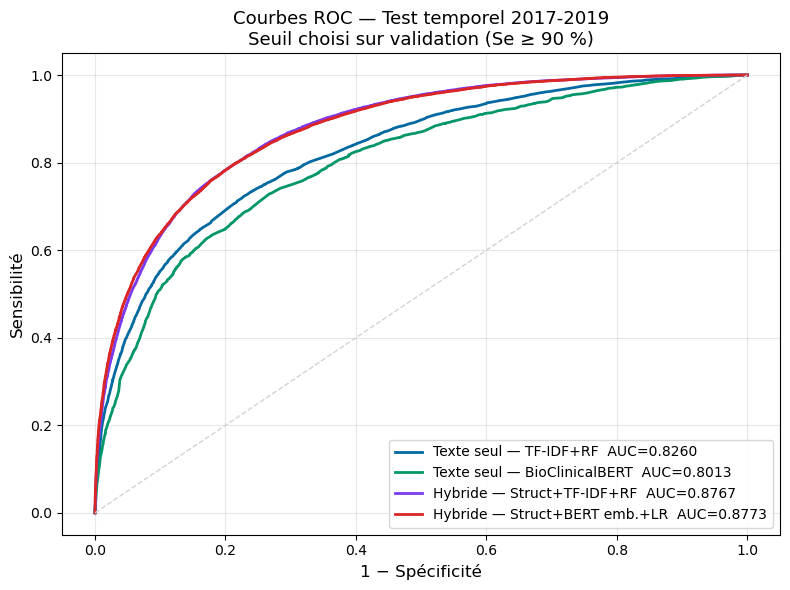

In [7]:
plot_roc_curves(probas, y_test, BERT_DIR)

#### Figure 45 — AUC et bootstrap apparié

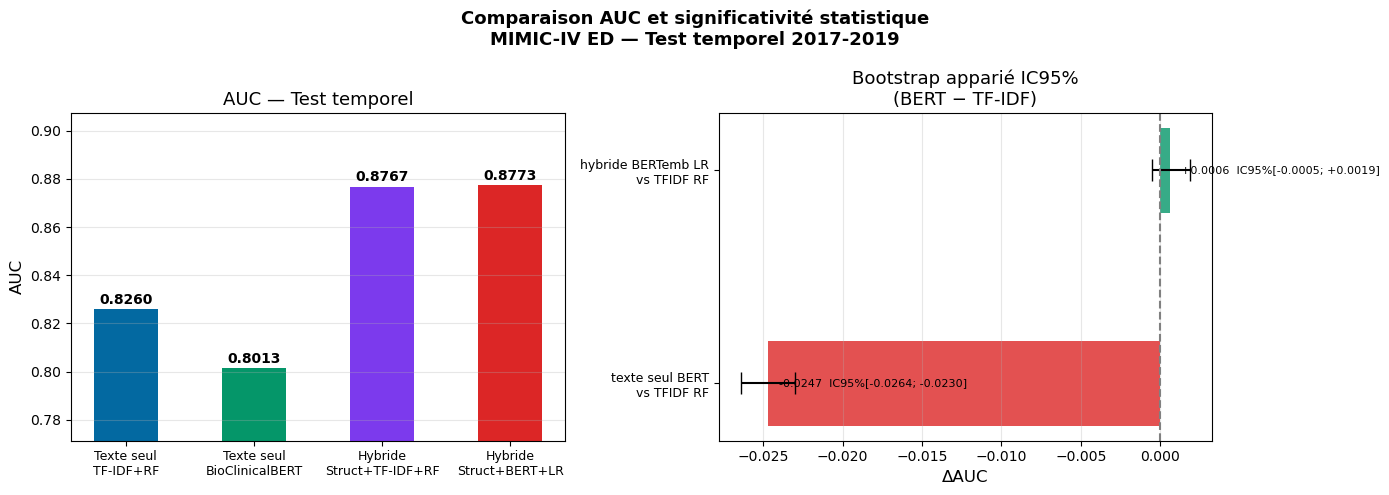

In [8]:
plot_auc_bootstrap(probas, y_test, comparisons, BERT_DIR)

#### Figure 46a — Matrice de confusion : TF-IDF + RF texte seul

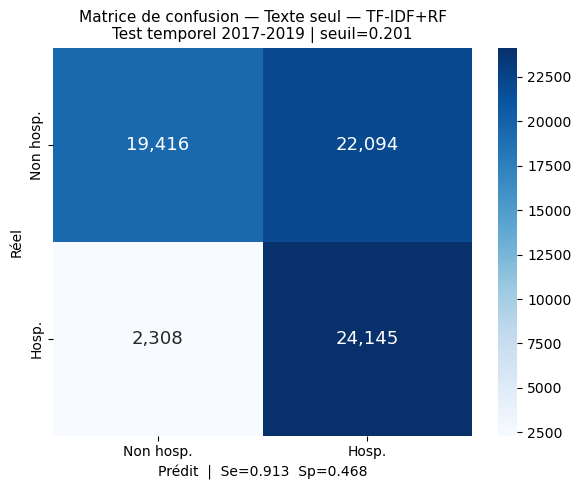

In [9]:
plot_confusion_matrix_one("text_tfidf_rf", probas, y_test, results, BERT_DIR)

#### Figure 46b — Matrice de confusion : BioClinicalBERT texte seul

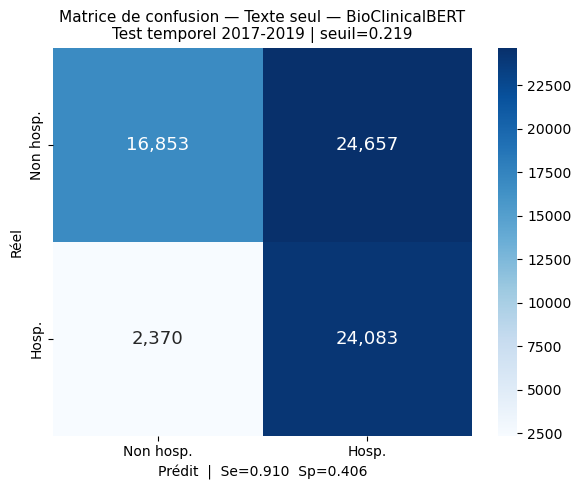

In [10]:
plot_confusion_matrix_one("text_bert", probas, y_test, results, BERT_DIR)

#### Figure 46c — Matrice de confusion : hybride Struct + TF-IDF + RF

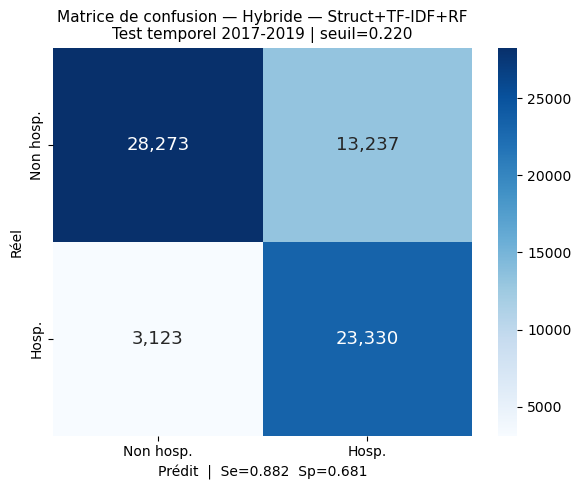

In [11]:
plot_confusion_matrix_one("hybrid_struct_tfidf_rf", probas, y_test, results, BERT_DIR)

#### Figure 46d — Matrice de confusion : hybride Struct + BERT embeddings + LR

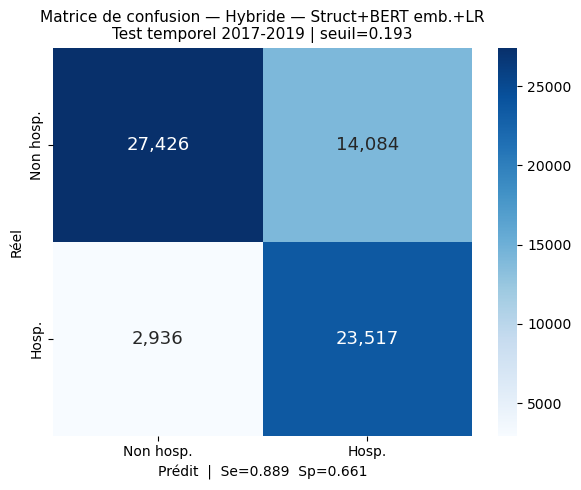

In [12]:
plot_confusion_matrix_one("hybrid_struct_bert_embeddings_lr", probas, y_test, results, BERT_DIR)

#### Figure 47 — Distribution des probabilités

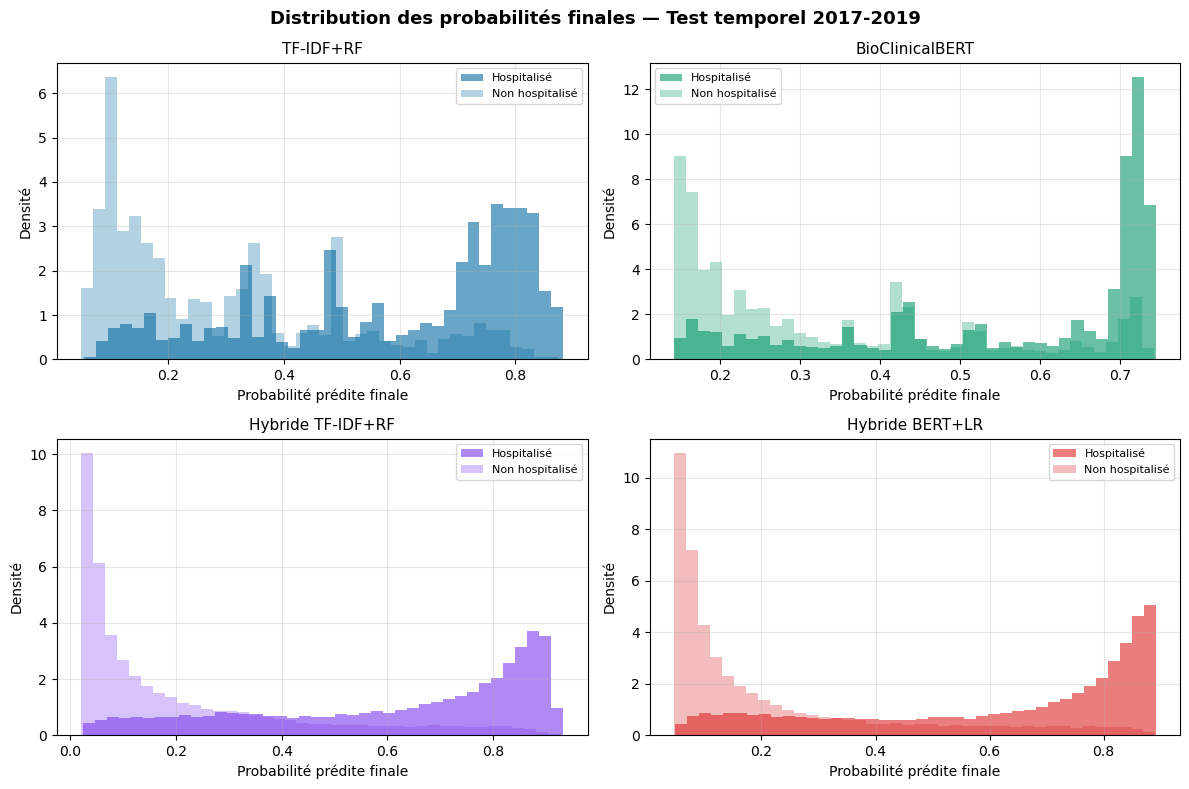

In [13]:
plot_distributions(probas, y_test, BERT_DIR)

#### Figure 48 — Tableau des métriques

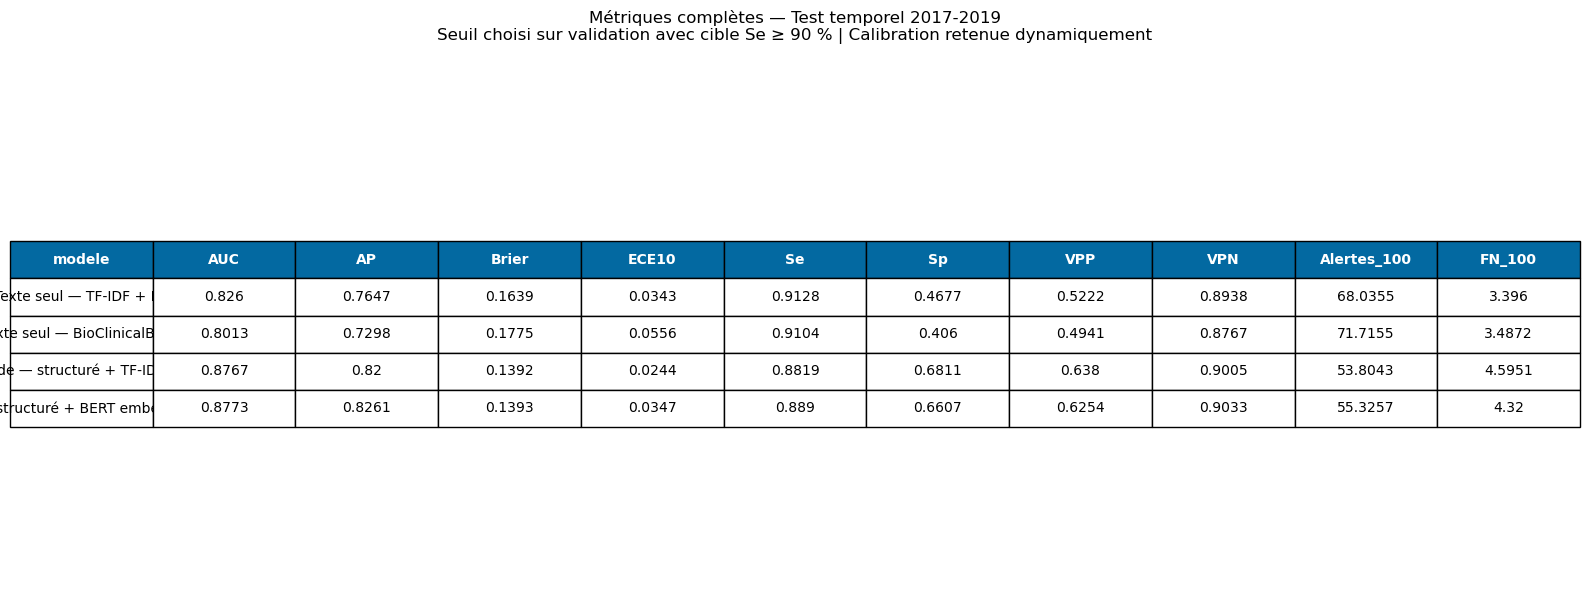

In [14]:
plot_metrics_table(results, BERT_DIR)

---
## 4. Résultats synthétiques

In [15]:
metrics_path = BERT_DIR / "metrics_final_test_temporel.csv"
comparisons_path = BERT_DIR / "comparaisons_bootstrap_auc.json"

if metrics_path.exists():
    metrics = pd.read_csv(metrics_path)
    display(metrics.round(4))
else:
    print(f"Métriques absentes : {metrics_path}")

if comparisons_path.exists():
    with open(comparisons_path, encoding="utf-8") as f:
        print(json.dumps(json.load(f), indent=2, ensure_ascii=False))
else:
    print(f"Comparaisons bootstrap absentes : {comparisons_path}")


,modele,n,threshold,AUC,AP,Brier,ECE10,Se,Sp,VPP,...,VP_100,FP_100,FN_100,calibration_retenue,brier_val_brut,brier_val_platt,delta_brier_val_platt_moins_brut,ece_val_brut,ece_val_platt,delta_ece_val_platt_moins_brut
0,Texte seul — TF-IDF + RF,67963,0.2009,0.8260,0.7647,0.1639,0.0343,0.9128,0.4677,0.5222,...,35.5267,32.5089,3.3960,platt,0.1876,0.1794,-0.0082,0.0889,0.0152,-0.0737
1,Texte seul — BioClinicalBERT,67963,0.2194,0.8013,0.7298,0.1775,0.0556,0.9104,0.4060,0.4941,...,35.4355,36.2800,3.4872,platt,0.1795,0.1771,-0.0024,0.0642,0.0576,-0.0066
2,Hybride — structuré + TF-IDF + RF,67963,0.2195,0.8767,0.8200,0.1392,0.0244,0.8819,0.6811,0.6380,...,34.3275,19.4768,4.5951,platt,0.1617,0.1520,-0.0098,0.0894,0.0141,-0.0753
3,Hybride — structuré + BERT embeddings + LR,67963,0.1933,0.8773,0.8261,0.1393,0.0347,0.8890,0.6607,0.6254,...,34.6027,20.7230,4.3200,platt,0.1566,0.1519,-0.0047,0.0715,0.0302,-0.0413


{
  "texte_seul_BERT_moins_TFIDF_RF": {
    "delta_auc_mean": -0.02472526855681642,
    "delta_auc_p2_5": -0.02638751835179185,
    "delta_auc_p97_5": -0.023022361814050037,
    "n_boot_effectif": 1000
  },
  "hybride_BERTemb_LR_moins_TFIDF_RF": {
    "delta_auc_mean": 0.0006110936690092085,
    "delta_auc_p2_5": -0.0005481812919400475,
    "delta_auc_p97_5": 0.0018643388086636902,
    "n_boot_effectif": 1000
  }
}


---
## 5. Fichiers produits

In [16]:
# Vérification finale des fichiers produits 
fichiers = [
    "metrics_final_test_temporel.csv",
    "comparaisons_bootstrap_auc.json",
    "split_trace.pkl",
    "fig44_bert_roc_curves.png",
    "fig45_bert_auc_bootstrap.png",
    "fig46_bert_confusion_matrix_text_tfidf_rf.png",
    "fig46_bert_confusion_matrix_text_bert.png",
    "fig46_bert_confusion_matrix_hybrid_struct_tfidf_rf.png",
    "fig46_bert_confusion_matrix_hybrid_struct_bert_embeddings_lr.png",
    "fig47_bert_distributions.png",
    "fig48_bert_metrics_table.png",
    "proba_test_text_tfidf_rf.npy",
    "proba_test_text_bert.npy",
    "proba_test_hybrid_struct_tfidf_rf.npy",
    "proba_test_hybrid_struct_bert_embeddings_lr.npy",
]

print("Fichiers sauvegardés :")
for f in fichiers: 
    print(f"  {f}")

Fichiers sauvegardés :
  metrics_final_test_temporel.csv
  comparaisons_bootstrap_auc.json
  split_trace.pkl
  fig44_bert_roc_curves.png
  fig45_bert_auc_bootstrap.png
  fig46_bert_confusion_matrix_text_tfidf_rf.png
  fig46_bert_confusion_matrix_text_bert.png
  fig46_bert_confusion_matrix_hybrid_struct_tfidf_rf.png
  fig46_bert_confusion_matrix_hybrid_struct_bert_embeddings_lr.png
  fig47_bert_distributions.png
  fig48_bert_metrics_table.png
  proba_test_text_tfidf_rf.npy
  proba_test_text_bert.npy
  proba_test_hybrid_struct_tfidf_rf.npy
  proba_test_hybrid_struct_bert_embeddings_lr.npy


---
## Conclusion de l'analyse secondaire

Cette analyse sert uniquement à vérifier si une représentation sémantique de type BioClinicalBERT améliore la prédiction par rapport à TF-IDF. Les résultats produits par ce notebook doivent être interprétés comme une analyse exploratoire complémentaire : le modèle opérationnel principal reste celui développé dans les notebooks de modélisation.